In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from new_data import TimeSeries
import os


ImportError: cannot import name 'TimeSeries' from 'new_data' (c:\Users\User\OneDrive\Área de Trabalho\PRCP_RDA_ANALISIS\new_data.py)

# Leitura do Conjunto de Dados

In [2]:
pasta = "(CSV) DATA_CPC_UNI_PRCP-GAUGE_GLB-RT-20261002T213012Z-1-001/(CSV) DATA_CPC_UNI_PRCP-GAUGE_GLB-RT"
lista_dfs = []

# Lê todos os arquivos CSV da pasta
for ficheiro in sorted(os.listdir(pasta)):
    if ficheiro.endswith(".csv"):
        caminho_csv = os.path.join(pasta, ficheiro)
        # Lê o CSV individual
        dados_ano = pd.read_csv(caminho_csv, sep=";")
        # Adiciona na lista
        lista_dfs.append(dados_ano)

# Concatena (junta) todas as tabelas em um único DataFrame
df_completo = pd.concat(lista_dfs, ignore_index=True)

# Visualiza as informações
print(f"Total de linhas combinadas: {len(df_completo)}")
display(df_completo)

Total de linhas combinadas: 750321


,data,lat,lon,precip_mm
0,2006-01-01,-7.75,-41.25,5.292850
1,2006-01-01,-7.75,-40.75,10.205985
2,2006-01-01,-7.75,-40.25,20.805733
3,2006-01-01,-7.75,-39.75,6.968030
4,2006-01-01,-7.75,-39.25,0.812125
...,...,...,...,...
750316,2026-09-29,-2.75,-39.25,NaN
750317,2026-09-29,-2.75,-38.75,NaN
750318,2026-09-29,-2.75,-38.25,NaN
750319,2026-09-29,-2.75,-37.75,NaN


In [4]:
df_completo.describe()

,lat,lon,precip_mm
count,750321.00000,750321.000000,666864.000000
mean,-5.25000,-39.250000,21.461001
std,1.58114,1.290995,59.904140
min,-7.75000,-41.250000,0.000000
25%,-6.75000,-40.250000,0.000000
50%,-5.25000,-39.250000,0.000000
75%,-3.75000,-38.250000,10.014323
max,-2.75000,-37.250000,1634.727295


In [5]:
df_completo.columns

Index(['data', 'lat', 'lon', 'precip_mm'], dtype='str')

In [6]:
df_completo.isna()

,data,lat,lon,precip_mm
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
750316,False,False,False,True
750317,False,False,False,True
750318,False,False,False,True
750319,False,False,False,True


In [7]:
df_completo.isna().sum()

data             0
lat              0
lon              0
precip_mm    83457
dtype: int64

In [8]:
df_completo.dtypes

data             str
lat          float64
lon          float64
precip_mm    float64
dtype: object

In [9]:
df_completo.info()

<class 'pandas.DataFrame'>
RangeIndex: 750321 entries, 0 to 750320
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   data       750321 non-null  str    
 1   lat        750321 non-null  float64
 2   lon        750321 non-null  float64
 3   precip_mm  666864 non-null  float64
dtypes: float64(3), str(1)
memory usage: 22.9 MB


# Estatística Descritiva

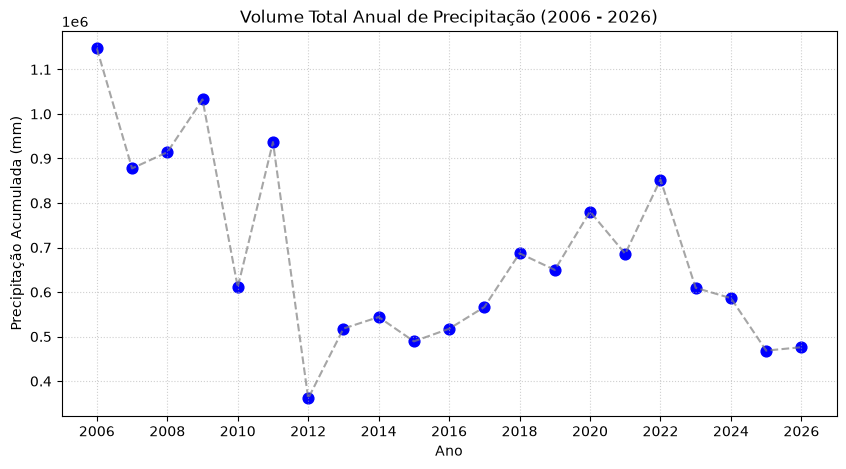

In [10]:
# 1. Garantir que a coluna de data está no formato correto
df_completo['data'] = pd.to_datetime(df_completo['data'])

# 2. Criar a coluna de Ano
df_completo['ano'] = df_completo['data'].dt.year

# 3. Calcular o volume total de chuva por ano
total_anual = df_completo.groupby('ano')['precip_mm'].sum().reset_index()

# 4. Gráfico de dispersão (Scatter Plot) ou Linha Anual
plt.figure(figsize=(10, 5))
plt.scatter(total_anual['ano'], total_anual['precip_mm'], color='blue', s=60)
plt.plot(
    total_anual['ano'],
    total_anual['precip_mm'],
    linestyle='--',
    color='gray',
    alpha=0.7,
)

plt.title('Volume Total Anual de Precipitação (2006 - 2026)')
plt.xlabel('Ano')
plt.ylabel('Precipitação Acumulada (mm)')
plt.xticks(range(2006, 2027, 2))  # Exibe de 2 em 2 anos no eixo X
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
df_completo["data].value_counts(sort=False, bins=10)

(2005-12-24 10:10:33.599999, 2008-01-28 14:24:00]    75042
(2008-01-28 14:24:00, 2010-02-24 04:48:00]           75240
(2010-02-24 04:48:00, 2012-03-22 19:12:00]           74943
(2012-03-22 19:12:00, 2014-04-19 09:36:00]           75042
(2014-04-19 09:36:00, 2016-05-16 00:00:00]           75042
(2016-05-16 00:00:00, 2018-06-12 14:24:00]           74943
(2018-06-12 14:24:00, 2020-07-09 04:48:00]           75042
(2020-07-09 04:48:00, 2022-08-05 19:12:00]           74943
(2022-08-05 19:12:00, 2024-09-01 09:36:00]           75042
(2024-09-01 09:36:00, 2026-09-29 00:00:00]           75042
Name: count, dtype: int64

In [22]:
df_completo["precip_mm"].value_counts(sort=False, bins=15)

(-1.636, 108.982]       626511
(108.982, 217.964]       26683
(217.964, 326.945]        8345
(326.945, 435.927]        3121
(435.927, 544.909]        1275
(544.909, 653.891]         545
(653.891, 762.873]         231
(762.873, 871.855]          92
(871.855, 980.836]          39
(980.836, 1089.818]         13
(1089.818, 1198.8]           7
(1198.8, 1307.782]           1
(1307.782, 1416.764]         0
(1416.764, 1525.745]         0
(1525.745, 1634.727]         1
Name: count, dtype: int64

<Axes: xlabel='Intervalo'>

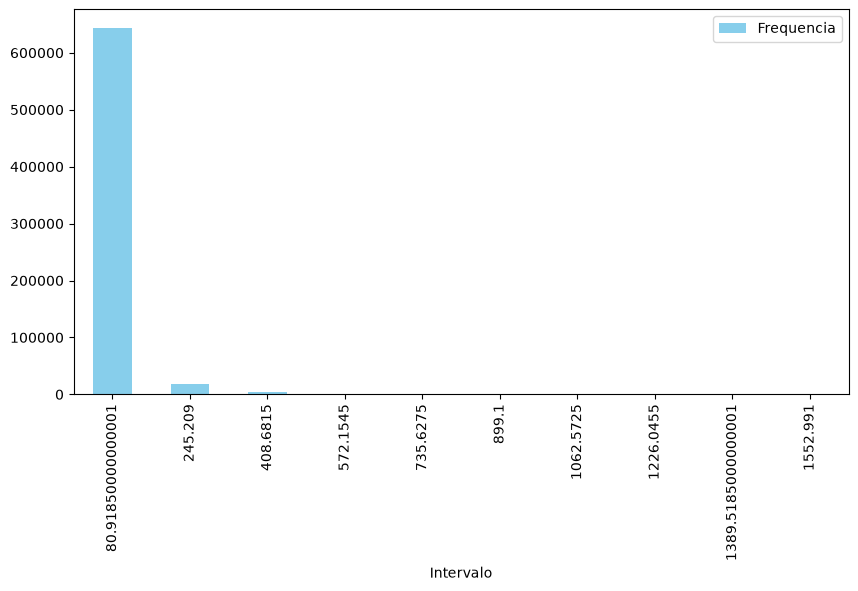

In [28]:
freq_i = df_completo["precip_mm"].value_counts(sort=False, bins=10)

freq_i_data = pd.DataFrame({
    "Intervalo" : freq_i.index.mid,
    "Frequencia" : freq_i.values
})

freq_i_data.plot(x="Intervalo", y="Frequencia", kind="bar", figsize=(10, 5), color='skyblue')

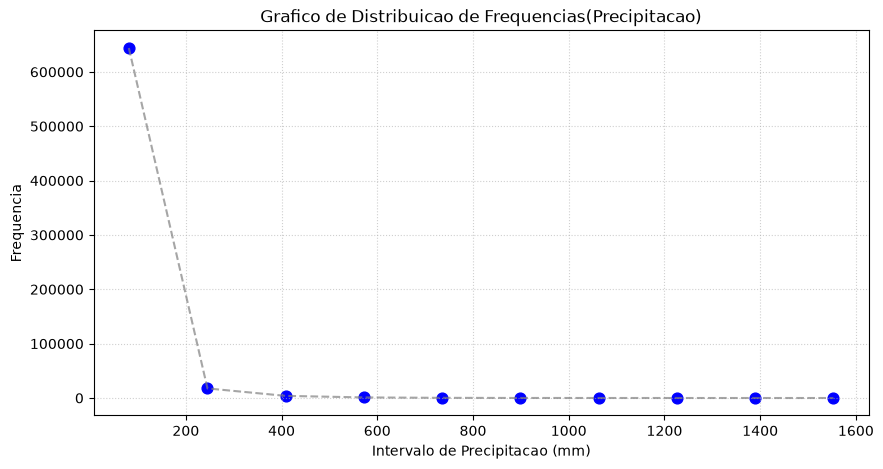

In [29]:
freq_i = df_completo["precip_mm"].value_counts(sort=False, bins=10)

freq_i_data = pd.DataFrame({
    "Intervalo" : freq_i.index.mid,
    "Frequencia" : freq_i.values
})

plt.figure(figsize=(10, 5))
plt.scatter(freq_i_data['Intervalo'], freq_i_data['Frequencia'], color='blue', s=60)
plt.plot(
    freq_i_data['Intervalo'],
    freq_i_data['Frequencia'],
    linestyle='--',
    color='gray',
    alpha=0.7,
)

plt.title('Grafico de Distribuicao de Frequencias(Precipitacao)')
plt.xlabel('Intervalo de Precipitacao (mm)')
plt.ylabel('Frequencia')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()